<a href="https://colab.research.google.com/github/stefanogiagu/corso_AI_2026/blob/main/ReadGraph_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download Dataset
Si utilizza il codice in preso dal github del corso per scaricare il dataset nel corretto formato

In [1]:
!pip install torch_geometric

In [2]:
print('Downloading datasets')

!rm -rf g11.col
!wget https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g11.col

!rm -rf g17.col
!wget https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g17.col

print('Done')

--2026-05-29 19:03:21--  https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g11.col
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2504 (2.4K) [text/plain]
Saving to: ‘g11.col’

g11.col             100%[===================>]   2.45K  --.-KB/s    in 0s      

2026-05-29 19:03:22 (46.0 MB/s) - ‘g11.col’ saved [2504/2504]

--2026-05-29 19:03:22--  https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g17.col
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35514 (35K) [text/plain]
Saving to: ‘g1

In [3]:
from pathlib import Path
from typing import Optional, Tuple, List, Dict, Union
import urllib.request

import torch
from torch_geometric.data import Data


def read_dimacs_col(
    path: Union[str, Path],
    make_undirected: bool = True,
    remove_self_loops: bool = True,
    dtype: torch.dtype = torch.float32,
) -> Data:
    """
    Read a graph coloring instance in DIMACS .col format and convert it
    to a PyTorch Geometric Data object.

    Expected DIMACS format:
        c comment lines
        p edge <num_nodes> <num_edges>
        e <u> <v>

    DIMACS nodes are usually 1-indexed.
    PyTorch Geometric expects 0-indexed node indices.

    Parameters
    ----------
    path:
        Path to the .col file.
    make_undirected:
        If True, each edge (u, v) is stored as both (u, v) and (v, u)
        in edge_index, as commonly expected by PyG message passing layers.
    remove_self_loops:
        If True, discard edges of the form (u, u).
    dtype:
        dtype for the default node features.

    Returns
    -------
    data:
        torch_geometric.data.Data object with fields:
            x: dummy node features, shape [num_nodes, 1]
            edge_index: graph connectivity, shape [2, num_edges_pyg]
            num_nodes: number of nodes
            name: file stem
            num_edges_dimacs: number of undirected edges declared/read
    """

    path = Path(path)

    if path.suffix == ".b" or path.name.endswith(".col.b"):
        raise ValueError(
            f"{path.name} appears to be a binary .col.b file. "
            "This parser only supports standard text DIMACS .col files."
        )

    num_nodes: Optional[int] = None
    declared_num_edges: Optional[int] = None
    edges: List[Tuple[int, int]] = []

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            # Comment line
            if parts[0] == "c":
                continue

            # Problem line: p edge n m
            if parts[0] == "p":
                if len(parts) < 4:
                    raise ValueError(
                        f"Malformed problem line at line {line_number}: {line}"
                    )

                problem_type = parts[1]
                if problem_type not in {"edge", "col"}:
                    # Most coloring instances use 'p edge n m'
                    # but we allow other variants with a warning-like behavior.
                    pass

                num_nodes = int(parts[2])
                declared_num_edges = int(parts[3])
                continue

            # Edge line: e u v
            if parts[0] == "e":
                if len(parts) < 3:
                    raise ValueError(
                        f"Malformed edge line at line {line_number}: {line}"
                    )

                # Convert from 1-indexed DIMACS to 0-indexed PyG.
                u = int(parts[1]) - 1
                v = int(parts[2]) - 1

                if remove_self_loops and u == v:
                    continue

                edges.append((u, v))
                continue

            # Ignore unknown line types, but this can be made stricter if desired.
            # raise ValueError(f"Unknown line type at line {line_number}: {line}")

    if num_nodes is None:
        raise ValueError(f"No problem line 'p edge n m' found in {path}")

    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        # Remove duplicate undirected edges robustly.
        # DIMACS stores undirected edges; we canonicalize as (min, max).
        unique_edges = set()
        for u, v in edges:
            if u < 0 or v < 0 or u >= num_nodes or v >= num_nodes:
                raise ValueError(
                    f"Edge ({u + 1}, {v + 1}) out of bounds for graph "
                    f"with {num_nodes} nodes in file {path}"
                )

            a, b = min(u, v), max(u, v)
            unique_edges.add((a, b))

        edge_list = sorted(unique_edges)

        if make_undirected:
            pyg_edges = edge_list + [(v, u) for u, v in edge_list]
        else:
            pyg_edges = edge_list

        edge_index = torch.tensor(pyg_edges, dtype=torch.long).t().contiguous()

    # Dummy node features.
    # For graph coloring, the learnable node embeddings can be created later
    # inside the model, but PyG Data objects usually contain x.
    x = torch.ones((num_nodes, 1), dtype=dtype)

    data = Data(
        x=x,
        edge_index=edge_index,
        num_nodes=num_nodes,
    )

    data.name = path.stem.replace(".col", "")
    data.num_edges_dimacs = len(edges)
    data.num_edges_unique = edge_index.size(1) // 2 if make_undirected else edge_index.size(1)
    data.declared_num_edges = declared_num_edges

    if declared_num_edges is not None and declared_num_edges != len(edges):
        data.edge_count_warning = (
            f"Declared {declared_num_edges} edges, read {len(edges)} edge lines."
        )
    else:
        data.edge_count_warning = None

    return data

In [4]:
data11 = read_dimacs_col("g11.col")
data17 = read_dimacs_col("g17.col")

print(data11)
print("Name:", data11.name)
print("Number of nodes:", data11.num_nodes)
print("DIMACS edges:", data11.num_edges_unique)
print("PyG edge_index shape:", data11.edge_index.shape)
print('\n')
print(data17)
print("Name:", data17.name)
print("Number of nodes:", data17.num_nodes)
print("DIMACS edges:", data17.num_edges_unique)
print("PyG edge_index shape:", data17.edge_index.shape)

Data(x=[25, 1], edge_index=[2, 320], num_nodes=25, name='g11', num_edges_dimacs=320, num_edges_unique=160, declared_num_edges=320)
Name: g11
Number of nodes: 25
DIMACS edges: 160
PyG edge_index shape: torch.Size([2, 320])


Data(x=[128, 1], edge_index=[2, 4226], num_nodes=128, name='g17', num_edges_dimacs=4226, num_edges_unique=2113, declared_num_edges=4226)
Name: g17
Number of nodes: 128
DIMACS edges: 2113
PyG edge_index shape: torch.Size([2, 4226])


Visualizzazione dei grafi

Text(0.5, 1.0, 'G17')

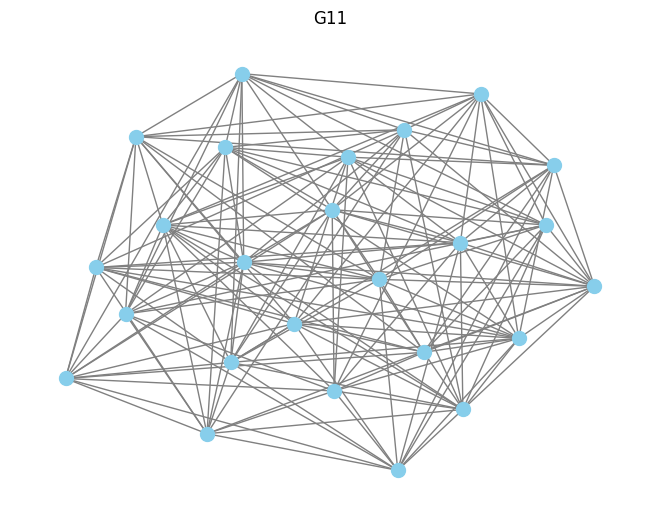

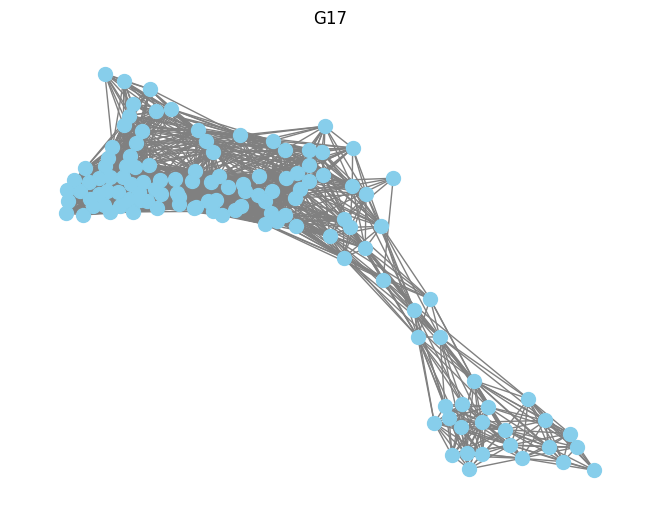

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

G = to_networkx(data11, to_undirected=True)
pos = nx.spring_layout(G)
plt.figure()
nx.draw(
    G, 
    pos, 
    node_color='skyblue', 
    edge_color='gray', 
    node_size=100, 
    font_size=10, 
)
plt.title('G11')

G = to_networkx(data17, to_undirected=True)
pos = nx.spring_layout(G)
plt.figure()
nx.draw(
    G, 
    pos, 
    node_color='skyblue', 
    edge_color='gray', 
    node_size=100, 
    font_size=10, 
)
plt.title('G17')



# Architettura del modello

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class ColoraGrafo(nn.Module):
    def __init__(self, num_nodes, c=5, hidden=64):
        super().__init__()

        self.embedding = nn.Embedding(num_nodes, hidden)
        self.conv1 = SAGEConv(hidden, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        #self.conv3 = SAGEConv(hidden, hidden)
        self.fc_out = nn.Linear(hidden, c)

    def forward(self, data):
        edge_index = data.edge_index    
        node_indices = torch.arange(self.embedding.num_embeddings, device=edge_index.device)        
        x = self.embedding(node_indices)
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        #x = F.relu(self.conv3(x, edge_index))
        x = self.fc_out(x)
        x = F.softmax(x, dim=-1)

        return x

In [7]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else print('Marta puzzi non hai messo le gpu')
print('Using',device, 'device')

# esempio di modello con g11
model = ColoraGrafo(num_nodes=data11.num_nodes).to(device)
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)

Using cuda device
ColoraGrafo(
  (embedding): Embedding(25, 64)
  (conv1): SAGEConv(64, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (conv3): SAGEConv(64, 64, aggr=mean)
  (fc_out): Linear(in_features=64, out_features=5, bias=True)
)
Numero di parametri trainabili: 26693


# Loss, metriche e ottimizzatore

In [8]:
# definizione della loss
def potts_energy_differentiable(pred, edge_index):
    """
    colori -> [num_nodes, c]
    calcolo l'energia di potts in formato differenziabile
    """
    i, j = edge_index

    edge_energy = (pred[i]*pred[j]).sum(dim=-1)
    return edge_energy.sum()

def entropic_term(pred):
    return ((pred+1e-12).log()*pred).sum()

def my_loss(pred, edge_index, ll):
    energy = potts_energy_differentiable(pred, edge_index)
    entropy = entropic_term(pred)
    return energy + ll*entropy

# come metrica utilizziamo il numero di conflitti
def pott_energy_normal(pred, edge_index):
    """
    Come prima ma con argmax prima
    """

    i, j = edge_index
    colori = pred.argmax(dim=-1)
    edge_energy = (colori[i] == colori[j]).int()
    return edge_energy.sum()
    
    

In [9]:
# proviamo a vedere che tutto funzioni
data11.x = torch.randn(data11.num_nodes, 1)
data11 = data11.to(device)


pred = model(data11)

loss = my_loss(pred, data11.edge_index, 0.01)
conflitti = pott_energy_normal(pred, data11.edge_index)

print('Loss: ', loss.item())
print('N conflitti: ', conflitti.item())

Loss:  63.745033264160156
N conflitti:  320


# Addestramento

# Addestro il grafo 11

In [ ]:
# baseline greedy con greedy_color
G = to_networkx(data11, to_undirected=True)
coloring = nx.coloring.greedy_color(G, strategy="largest_first")
num_colors = max(coloring.values()) + 1
print("Baseline greedy: c=", num_colors)

Baseline greedy: c= 7


In [10]:
import torch.optim as optim
num_epochs = 200
c=7
# imposto l'iper-parametro
ll = 0.05
data11.x = torch.randn(data11.num_nodes, 1)
data = data11.to(device)
model11 = ColoraGrafo(num_nodes=data.num_nodes, c=c).to(device)
optimizer11 = optim.Adam(model11.parameters(), lr = 0.003)

train_curve = []
conflicts_curve = []

for epoch in range(num_epochs):
    model11.train()
    
    # forward pass
    output = model11(data)
    loss = my_loss(output, data.edge_index, ll)

    # backward pass and backpropagation
    optimizer11.zero_grad()
    loss.backward()
    optimizer11.step()

    # calcolo i conflitti 
    #model11.eval()
    conflicts = pott_energy_normal(output, data.edge_index)

    # salvo loss e conflitti
    train_curve.append(loss.cpu().detach().numpy())
    conflicts_curve.append(conflicts.cpu().detach().numpy())

    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Conflicts: {conflicts:.4f}")




Epoch 1, Loss: 43.6653, Conflicts: 296.0000
Epoch 2, Loss: 43.3079, Conflicts: 166.0000
Epoch 3, Loss: 43.3557, Conflicts: 124.0000
Epoch 4, Loss: 43.3058, Conflicts: 78.0000
Epoch 5, Loss: 43.2992, Conflicts: 74.0000
Epoch 6, Loss: 43.3026, Conflicts: 142.0000
Epoch 7, Loss: 43.2946, Conflicts: 112.0000
Epoch 8, Loss: 43.2873, Conflicts: 76.0000
Epoch 9, Loss: 43.2852, Conflicts: 62.0000
Epoch 10, Loss: 43.2860, Conflicts: 88.0000
Epoch 11, Loss: 43.2864, Conflicts: 60.0000
Epoch 12, Loss: 43.2857, Conflicts: 54.0000
Epoch 13, Loss: 43.2843, Conflicts: 40.0000
Epoch 14, Loss: 43.2826, Conflicts: 36.0000
Epoch 15, Loss: 43.2813, Conflicts: 34.0000
Epoch 16, Loss: 43.2805, Conflicts: 36.0000
Epoch 17, Loss: 43.2805, Conflicts: 38.0000
Epoch 18, Loss: 43.2807, Conflicts: 40.0000
Epoch 19, Loss: 43.2808, Conflicts: 46.0000
Epoch 20, Loss: 43.2804, Conflicts: 50.0000
Epoch 21, Loss: 43.2796, Conflicts: 42.0000
Epoch 22, Loss: 43.2786, Conflicts: 30.0000
Epoch 23, Loss: 43.2775, Conflicts: 

Text(0.5, 1.0, 'Esempio di ottimizzazione, c=7, g11')

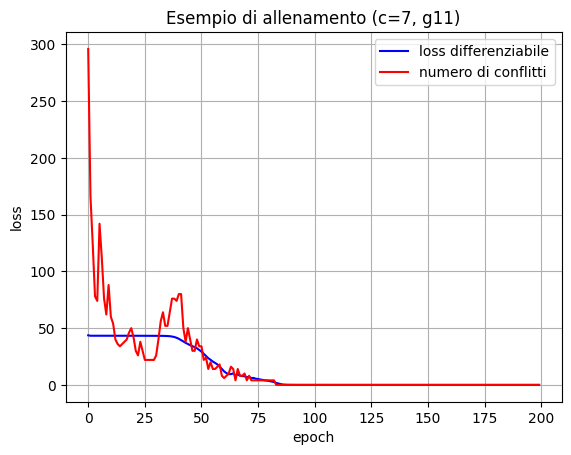

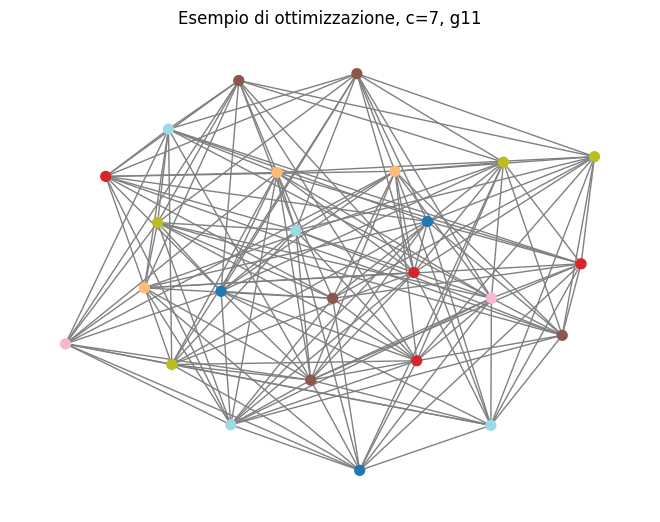

In [11]:
plt.figure()
plt.plot(train_curve, label = 'loss differenziabile', color = 'blue')
plt.plot(conflicts_curve, label = 'numero di conflitti', color = 'red')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title(f'Esempio di allenamento (c={c}, g11)')
plt.grid()
plt.legend()

def disegna_grafo_conflitti(model, data):
    node_colors = torch.argmax(model(data), dim=-1).cpu().numpy()
    #print(node_colors)
    G = to_networkx(data, to_undirected=True)
    pos = nx.spring_layout(G)
    nx.draw(
        G, 
        pos,  
        node_color=node_colors,
        edge_color='gray', 
        node_size=50, 
        font_size=10, 
        cmap=plt.cm.tab20,
    )
    vertici_conflitti = []
    for i, j in G.edges():
        if node_colors[i] == node_colors[j]:
            vertici_conflitti.append((i, j))
        
    nx.draw_networkx_edges(
            G, pos, 
            edgelist=vertici_conflitti, 
            edge_color='red', 
            width=2.5
        )
plt.figure()
disegna_grafo_conflitti(model11, data11)
plt.title(f'Esempio di ottimizzazione, c={c}, g11')

In [12]:
# preparo le funzioni per fare più allenamenti
import numpy as np
def oneTrain(data, c, num_epochs=400, ll=0.05):
    data.x = torch.randn(data.num_nodes, 1)
    data = data.to(device)
    model = ColoraGrafo(num_nodes = data.num_nodes, c=c).to(device)
    optimizer = optim.Adam(model.parameters(), lr = 0.001)
    model.train()
    for epoch in range(num_epochs):
    
        # forward pass
        output = model(data)
        loss = my_loss(output, data.edge_index, ll)

        # backward pass and backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # calcolo i conflitti 
        #model11.eval()
        conflicts = pott_energy_normal(output, data.edge_index)

        # salvo loss e conflitti
        #print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Conflicts: {conflicts:.4f}")
    

    return loss.cpu().detach().numpy(), conflicts.cpu().detach().numpy()


def train_ensemble(data, c, num_sim=50, num_epochs=400):
    conflitti = []
    colorazioni_perfette = 0
    for i in range(num_sim):
        temp, temp1 = oneTrain(data, c, num_epochs=num_epochs)
        conflitti.append(temp1)
        if temp1==0:
            colorazioni_perfette+=1

    conflitti = np.array([conflitti])
    return conflitti.mean(), conflitti.std(), colorazioni_perfette



In [ ]:
# adesso i loop di allenamenti
cmin = 2
cmax = 9
conflitti_medie = []
conflitti_std = []
frequenze_colorazioni = []
for c in range(cmin, cmax):
    media, dev, colorazioni_perfette = train_ensemble(data11, c)
    conflitti_medie.append(media)
    conflitti_std.append(dev)
    frequenze_colorazioni.append(colorazioni_perfette/float(50))
    print(c, media, dev,colorazioni_perfette)


2 123.44 1.3879481258317978 0
3 61.04 1.799555500672319 0
4 30.8 3.666060555964672 0
5 12.36 5.624091037669998 5
6 4.36 3.0117104774529704 11
7 1.44 1.92 28
8 0.36 0.7683749084919419 41


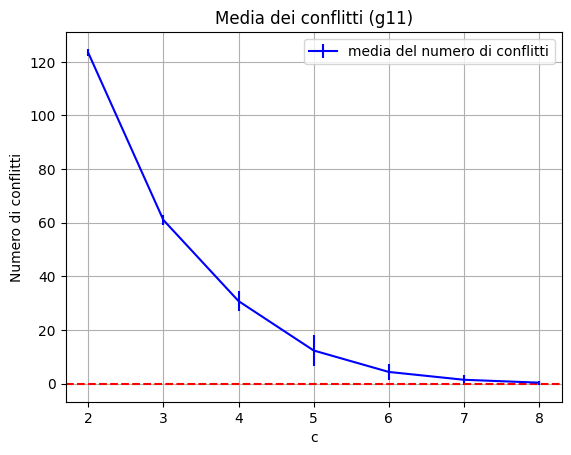

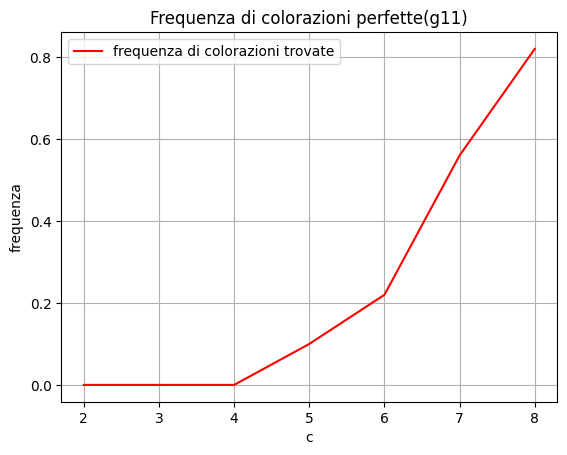

In [ ]:
plt.figure()
plt.errorbar(range(cmin, cmax), conflitti_medie, yerr=conflitti_std, label = 'media del numero di conflitti', color = 'blue')
plt.axhline(0, color='red', linestyle='--')

plt.title('Media dei conflitti (g11)')
plt.grid()
plt.xlabel('c')
plt.ylabel('Numero di conflitti')
plt.legend()

plt.figure()
plt.title('Frequenza di colorazioni perfette(g11)')
plt.xlabel('c')
plt.grid()
plt.ylabel('frequenza')
plt.plot(range(cmin, cmax), frequenze_colorazioni, color = 'red', label = 'frequenza di colorazioni trovate')
plt.legend()

# Addestro il grafo 17

In [ ]:
# baseline greedy con greedy_color
G = to_networkx(data17, to_undirected=True)
coloring = nx.coloring.greedy_color(G, strategy="largest_first")
num_colors = max(coloring.values()) + 1
print("Baseline greedy: c=", num_colors)

Baseline greedy: c= 32


In [15]:
import torch.optim as optim
num_epochs = 1000
c=35
# imposto l'iper-parametro
ll = 0.05
data17.x = torch.randn(data17.num_nodes, 1)
data = data17.to(device)
model17 = ColoraGrafo(num_nodes=data.num_nodes, c=c).to(device)
optimizer17 = optim.Adam(model17.parameters(), lr = 0.003)

train_curve = []
conflicts_curve = []

for epoch in range(num_epochs):
    model17.train()
    
    # forward pass
    output = model17(data)
    loss = my_loss(output, data.edge_index, ll)

    # backward pass and backpropagation
    optimizer17.zero_grad()
    loss.backward()
    optimizer17.step()

    # calcolo i conflitti 
    #model17.eval()
    conflicts = pott_energy_normal(output, data.edge_index)

    # salvo loss e conflitti
    train_curve.append(loss.cpu().detach().numpy())
    conflicts_curve.append(conflicts.cpu().detach().numpy())

    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Conflicts: {conflicts:.4f}")




Epoch 1, Loss: 98.9734, Conflicts: 1586.0000
Epoch 2, Loss: 98.3143, Conflicts: 960.0000
Epoch 3, Loss: 98.1597, Conflicts: 922.0000
Epoch 4, Loss: 98.0832, Conflicts: 1486.0000
Epoch 5, Loss: 98.0581, Conflicts: 612.0000
Epoch 6, Loss: 98.0382, Conflicts: 778.0000
Epoch 7, Loss: 98.0224, Conflicts: 414.0000
Epoch 8, Loss: 98.0166, Conflicts: 362.0000
Epoch 9, Loss: 98.0160, Conflicts: 342.0000
Epoch 10, Loss: 98.0149, Conflicts: 350.0000
Epoch 11, Loss: 98.0120, Conflicts: 334.0000
Epoch 12, Loss: 98.0086, Conflicts: 272.0000
Epoch 13, Loss: 98.0060, Conflicts: 268.0000
Epoch 14, Loss: 98.0041, Conflicts: 266.0000
Epoch 15, Loss: 98.0018, Conflicts: 316.0000
Epoch 16, Loss: 97.9988, Conflicts: 324.0000
Epoch 17, Loss: 97.9960, Conflicts: 258.0000
Epoch 18, Loss: 97.9941, Conflicts: 204.0000
Epoch 19, Loss: 97.9931, Conflicts: 214.0000
Epoch 20, Loss: 97.9928, Conflicts: 264.0000
Epoch 21, Loss: 97.9927, Conflicts: 276.0000
Epoch 22, Loss: 97.9926, Conflicts: 296.0000
Epoch 23, Loss: 9

In [ ]:
# qua si prova a migliorare a "mano" la soluzione ottenuta con la rete neurale


# identifico i conflitti
node_colors = torch.argmax(model(data17), dim=-1).cpu().numpy()
vertici_conflitti = []
for i, j in G.edges():
    if node_colors[i] == node_colors[j]:
        vertici_conflitti.append((i, j))

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Text(0.5, 1.0, 'Esempio di ottimizzazione, c=35, g17')

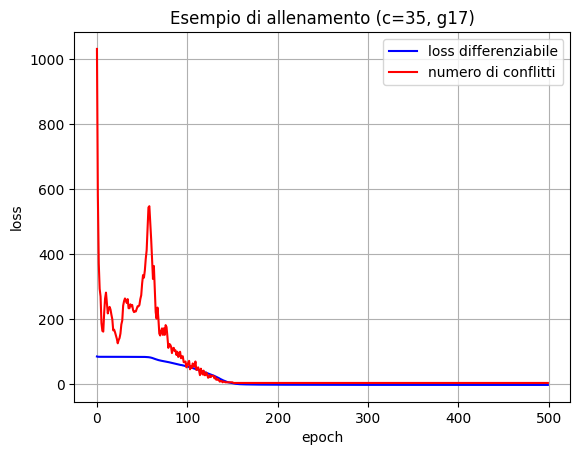

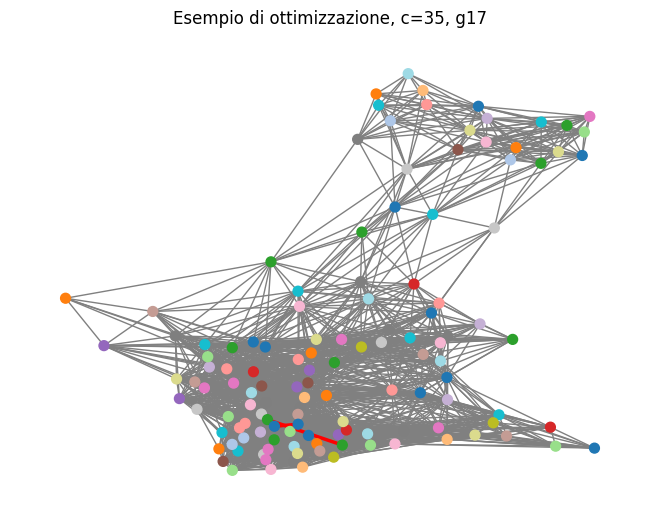

In [ ]:
plt.figure()
plt.plot(train_curve, label = 'loss differenziabile', color = 'blue')
plt.plot(conflicts_curve, label = 'numero di conflitti', color = 'red')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title(f'Esempio di allenamento (c={c}, g17)')
plt.grid()
plt.legend()

plt.figure()
disegna_grafo_conflitti(model17, data17)
plt.title(f'Esempio di ottimizzazione, c={c}, g17')

In [ ]:
# adesso i loop di allenamenti
cmin = 30
cmax = 36
conflitti_medie = []
conflitti_std = []
frequenze_colorazioni = []
for c in range(cmin, cmax):
    media, dev, colorazioni_perfette = train_ensemble(data17, c, num_epochs=500)
    conflitti_medie.append(media)
    conflitti_std.append(dev)
    frequenze_colorazioni.append(colorazioni_perfette/float(50))
    print(c, media, dev,colorazioni_perfette)

30 12.92 2.1985449733858076 0
31 11.2 2.0396078054371136 0
32 8.96 1.6608431593621358 0
33 7.52 2.3172397372736384 0
34 6.16 2.0333224043422136 0
35 4.16 1.7816845961056071 1


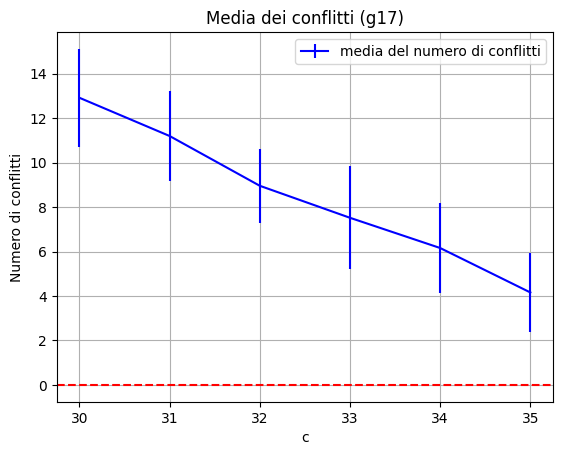

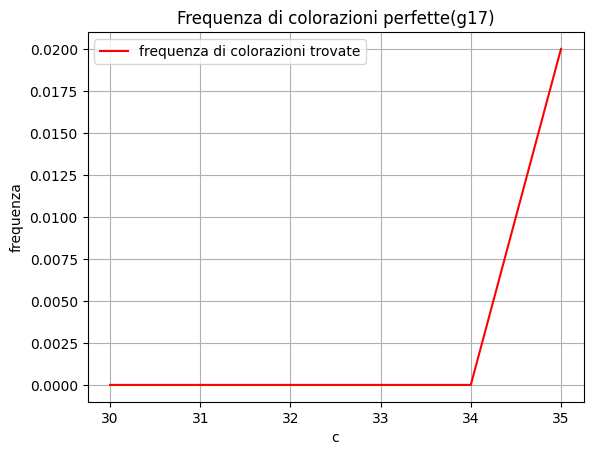

In [ ]:
plt.figure()
plt.errorbar(range(cmin, cmax), conflitti_medie, yerr=conflitti_std, label = 'media del numero di conflitti', color = 'blue')
plt.axhline(0, color='red', linestyle='--')

plt.title('Media dei conflitti (g17)')
plt.grid()
plt.xlabel('c')
plt.ylabel('Numero di conflitti')
plt.legend()

plt.figure()
plt.title('Frequenza di colorazioni perfette(g17)')
plt.xlabel('c')
plt.grid()
plt.ylabel('frequenza')
plt.plot(range(cmin, cmax), frequenze_colorazioni, color = 'red', label = 'frequenza di colorazioni trovate')
plt.legend()